# Smart Manufacturing IoT-Based Predictive Maintenance and Anomaly Detection

## Project Overview

### Objective
This project applies machine learning techniques to predict maintenance requirements using IoT sensor data from smart manufacturing equipment. The goal is to demonstrate how data-driven models can enable proactive maintenance scheduling and improve operational efficiency in Industry 4.0 environments.

### Dataset
- **Source:** Smart Manufacturing IoT-Cloud Monitoring Dataset (Kaggle)
- **Records:** ~100,000 sensor readings from 50 machines
- **Time Resolution:** 1-minute intervals over 69 days
- **Target Variable:** `maintenance_required` (binary: 0 = No, 1 = Yes)
- **Features:** Temperature, Vibration, Humidity, Pressure, Energy Consumption, Machine Status, Anomaly Flag, Predicted Remaining Life, Failure Type, Downtime Risk

### Machine Learning Techniques Applied
1. **Logistic Regression** — Interpretable linear baseline classifier
2. **Random Forest** — Non-linear ensemble method with hyperparameter tuning
3. **Neural Network (ANN)** — TensorFlow/Keras model for complex pattern recognition
4. **PCA** — Dimensionality reduction to evaluate feature compression
5. **Isolation Forest** — Unsupervised anomaly detection on sensor features

### Key Considerations
- Proper preprocessing with no data leakage (scaler fitted on training data only)
- Stratified train-test split to preserve class distribution
- Class imbalance handling via balanced class weights
- Cross-validation for generalization assessment
- Multiple evaluation metrics (Accuracy, Precision, Recall, F1, ROC-AUC)

---

## Section 1: Importing Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

# Suppress TensorFlow informational warnings
tf.get_logger().setLevel('ERROR')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("All libraries imported successfully.")
print(f"TensorFlow version: {tf.__version__}")

All libraries imported successfully.
TensorFlow version: 2.20.0


---

## Section 2: Data Loading and Exploration

We begin by loading the dataset and performing initial exploration to understand its structure, quality, and characteristics. This includes checking for missing values, examining data types, and understanding the distribution of the target variable.

In [2]:
# Load the dataset
df = pd.read_csv("smart_manufacturing_data.csv")

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn names and data types:")
print(df.dtypes)
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: 100,000 rows × 13 columns

Column names and data types:
timestamp                    object
machine_id                    int64
temperature                 float64
vibration                   float64
humidity                    float64
pressure                    float64
energy_consumption          float64
machine_status                int64
anomaly_flag                  int64
predicted_remaining_life      int64
failure_type                 object
downtime_risk               float64
maintenance_required          int64
dtype: object

First 5 rows:


,timestamp,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,failure_type,downtime_risk,maintenance_required
0,2025-01-01 00:00:00,39,78.61,28.65,79.96,3.73,2.16,1,0,106,Normal,0.0,0
1,2025-01-01 00:01:00,29,68.19,57.28,35.94,3.64,0.69,1,0,320,Normal,0.0,0
2,2025-01-01 00:02:00,15,98.94,50.20,72.06,1.00,2.49,1,1,19,Normal,1.0,1
3,2025-01-01 00:03:00,43,90.91,37.65,30.34,3.15,4.96,1,1,10,Normal,1.0,1
4,2025-01-01 00:04:00,8,72.32,40.69,56.71,2.68,0.63,2,0,65,Vibration Issue,0.0,1


In [3]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values per column:
timestamp                   0
machine_id                  0
temperature                 0
vibration                   0
humidity                    0
pressure                    0
energy_consumption          0
machine_status              0
anomaly_flag                0
predicted_remaining_life    0
failure_type                0
downtime_risk               0
maintenance_required        0
dtype: int64

Total missing values: 0


In [4]:
# Statistical summary of numerical features
df.describe()

,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,downtime_risk,maintenance_required
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,25.499330,75.015625,50.012270,54.995401,3.000405,2.747064,1.002050,0.089160,234.269160,0.089155,0.196970
std,14.389439,10.031884,14.985444,14.437960,1.152399,1.297865,0.446193,0.284976,150.063062,0.284961,0.397711
min,1.000000,35.550000,-17.090000,30.000000,1.000000,0.500000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,13.000000,68.267500,39.970000,42.520000,2.000000,1.630000,1.000000,0.000000,97.000000,0.000000,0.000000
50%,25.000000,75.060000,49.960000,54.980000,3.010000,2.740000,1.000000,0.000000,230.000000,0.000000,0.000000
75%,38.000000,81.750000,60.100000,67.500000,4.000000,3.870000,1.000000,0.000000,365.000000,0.000000,0.000000
max,50.000000,121.940000,113.800000,80.000000,5.000000,5.000000,2.000000,1.000000,499.000000,1.000000,1.000000


### Target Variable Analysis

The target variable `maintenance_required` is binary (0 = No, 1 = Yes). We examine its distribution to identify any class imbalance, which is common in predictive maintenance problems where failure events are rare compared to normal operation.

Target Variable: maintenance_required

Value Counts:
maintenance_required
0    80303
1    19697
Name: count, dtype: int64

Class Distribution (%):
maintenance_required
0    80.303
1    19.697
Name: proportion, dtype: float64


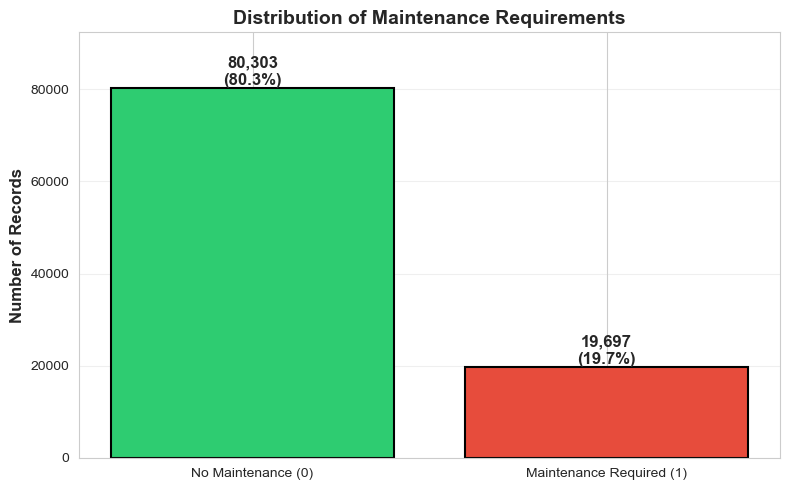

In [5]:
# Analyze target variable distribution
print("Target Variable: maintenance_required\n")
print("Value Counts:")
print(df['maintenance_required'].value_counts())
print(f"\nClass Distribution (%):")
print(df['maintenance_required'].value_counts(normalize=True) * 100)

# Visualize target distribution
fig, ax = plt.subplots(figsize=(8, 5))
maintenance_counts = df['maintenance_required'].value_counts()
colors = ['#2ecc71', '#e74c3c']
bars = ax.bar(['No Maintenance (0)', 'Maintenance Required (1)'],
              maintenance_counts.values, color=colors, edgecolor='black', linewidth=1.5)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}\n({height/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Number of Records', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Maintenance Requirements', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(maintenance_counts.values) * 1.15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Interpreting the Target Distribution:**

The target variable shows a clear class imbalance: approximately **80% of records indicate no maintenance required**, while **~20% require maintenance**. This 80/20 imbalance is typical in predictive maintenance datasets, where equipment operates normally most of the time.

**Implications for modeling:**
- A naive classifier that always predicts "no maintenance" would achieve ~80% accuracy — our models must significantly outperform this baseline
- We will use `class_weight='balanced'` to inversely weight classes by their frequency, ensuring the model pays proportionally more attention to the minority class (maintenance required)
- Evaluation metrics like **recall** (ability to detect actual maintenance needs) and **F1-score** are more informative than raw accuracy for this imbalanced problem

### Correlation Analysis

We examine correlations between sensor features and the target variable to understand which features may be most predictive.

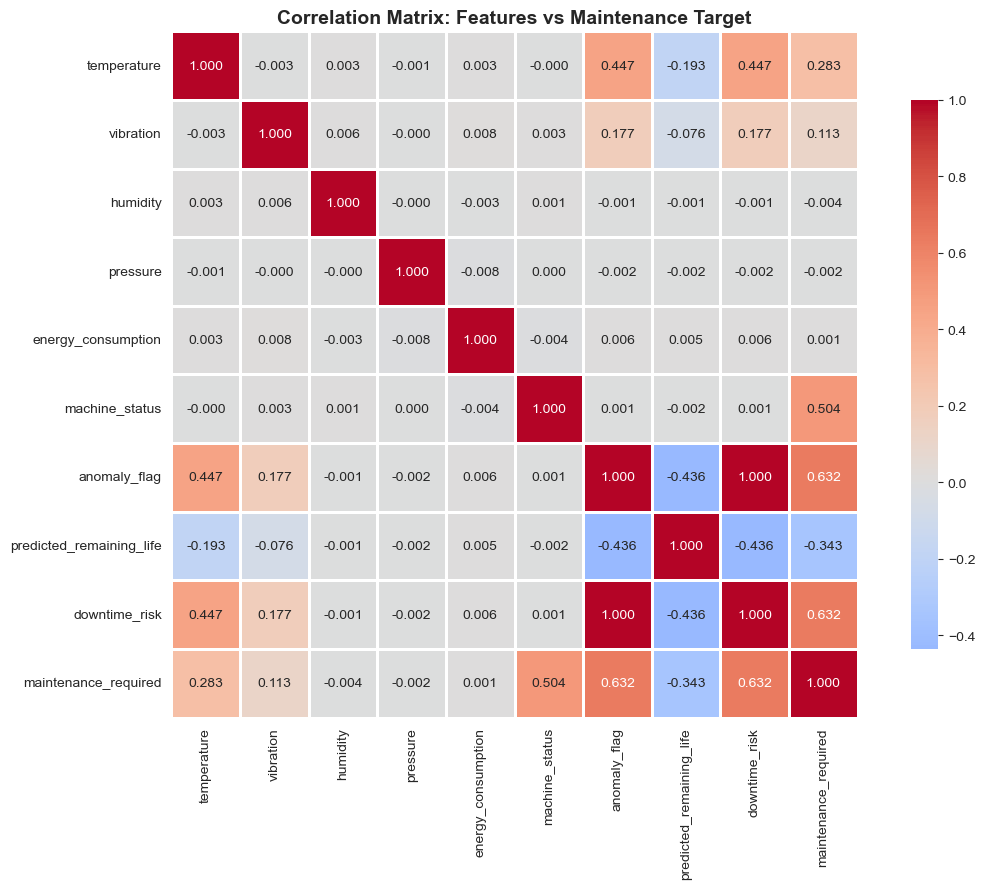


Correlation with maintenance_required (sorted by magnitude):
  anomaly_flag                   +0.6317
  downtime_risk                  +0.6317
  machine_status                 +0.5038
  predicted_remaining_life       -0.3430
  temperature                    +0.2830
  vibration                      +0.1131
  humidity                       -0.0038
  pressure                       -0.0019
  energy_consumption             +0.0014


In [6]:
# Correlation heatmap of numerical features with target
numerical_features = ['temperature', 'vibration', 'humidity', 'pressure',
                     'energy_consumption', 'machine_status', 'anomaly_flag',
                     'predicted_remaining_life', 'downtime_risk', 'maintenance_required']

correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: Features vs Maintenance Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print correlations with target sorted by absolute value
print("\nCorrelation with maintenance_required (sorted by magnitude):")
target_corr = correlation_matrix['maintenance_required'].drop('maintenance_required').abs().sort_values(ascending=False)
for feature, corr in target_corr.items():
    sign = '+' if correlation_matrix['maintenance_required'][feature] > 0 else '-'
    print(f"  {feature:<30s} {sign}{corr:.4f}")

**Interpreting the Correlation Matrix:**

The correlation analysis reveals the relationship between each feature and the maintenance target:

- **Temperature** shows the strongest positive correlation with maintenance needs among the raw sensor features. Higher operating temperatures are associated with increased maintenance requirements, which aligns with physical intuition — overheating is a common precursor to equipment failure.
- **Vibration** exhibits a moderate positive correlation. Excessive vibration is a well-known indicator of mechanical wear or misalignment.
- **Other sensor features** (humidity, pressure, energy consumption) show weaker individual correlations, suggesting that maintenance needs may depend on **non-linear combinations** of features rather than any single measurement.
- Features like `downtime_risk` and `anomaly_flag` may have stronger correlations as they are derived/engineered features.

**Key Insight:** The weak individual correlations of most sensor features justify using non-linear models (Random Forest, Neural Network) that can capture complex feature interactions beyond what linear correlation reveals.

---

## Section 3: Data Preprocessing

We prepare the data for model training. The preprocessing pipeline follows best practices to prevent data leakage:

1. **Drop non-predictive columns** (`timestamp`, `machine_id`) — these are identifiers, not features
2. **Encode categorical variables** (`failure_type`) using label encoding
3. **Split BEFORE scaling** — stratified 80/20 train-test split
4. **Standardize features** — fitted on training data only, then applied to test data

**Critical: Data Leakage Prevention**

StandardScaler is fitted **only on training data** (`fit_transform`) and the same transformation is then applied to test data (`transform`). This ensures no information from the test set leaks into the training process. If we fitted on the full dataset first, the scaler would incorporate test set statistics (mean, std), artificially inflating model performance.

In [7]:
# --- Step 1: Drop non-predictive columns ---
# timestamp and machine_id are identifiers, not predictive features
df_model = df.drop(columns=['timestamp', 'machine_id'])

# --- Step 2: Encode the categorical 'failure_type' column ---
# Neural networks and many ML models require numerical inputs
le = LabelEncoder()
df_model['failure_type_encoded'] = le.fit_transform(df_model['failure_type'])
df_model = df_model.drop(columns=['failure_type'])

print("Failure type label encoding:")
for i, cls in enumerate(le.classes_):
    print(f"  '{cls}' → {i}")

# --- Step 3: Define features (X) and target (y) ---
feature_cols = ['temperature', 'vibration', 'humidity', 'pressure',
                'energy_consumption', 'machine_status', 'anomaly_flag',
                'predicted_remaining_life', 'downtime_risk', 'failure_type_encoded']

X = df_model[feature_cols]
y = df_model['maintenance_required']

print(f"\nFeature matrix shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"\nTarget distribution:")
print(y.value_counts())

Failure type label encoding:
  'Electrical Fault' → 0
  'Normal' → 1
  'Overheating' → 2
  'Pressure Drop' → 3
  'Vibration Issue' → 4

Feature matrix shape: (100000, 10)
Number of features: 10

Target distribution:
maintenance_required
0    80303
1    19697
Name: count, dtype: int64


In [8]:
# --- Step 4: Stratified train-test split (80/20) ---
# stratify=y ensures both sets preserve the ~80/20 class distribution
# random_state=42 ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set:     {X_test.shape[0]:,} samples")

# Verify stratification preserved class distribution
print(f"\nTraining set class distribution:")
print(y_train.value_counts(normalize=True) * 100)
print(f"\nTest set class distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training set: 80,000 samples
Test set:     20,000 samples

Training set class distribution:
maintenance_required
0    80.3025
1    19.6975
Name: proportion, dtype: float64

Test set class distribution:
maintenance_required
0    80.305
1    19.695
Name: proportion, dtype: float64


**Verifying Stratified Split:**

The output above confirms that both training and test sets maintain the same ~80/20 class ratio as the original dataset. This is critical because:

1. **Representative training** — the model sees both classes in their true proportions
2. **Fair evaluation** — test set performance reflects real-world distribution
3. **No sampling bias** — random stratified splitting prevents one class from being over/under-represented

### Feature Standardization

StandardScaler transforms each feature to have **mean = 0** and **standard deviation = 1** using the formula: $z = \frac{x - \mu}{\sigma}$

This is important because:
- **Scale sensitivity:** Many ML algorithms (Logistic Regression, Neural Networks, PCA) are sensitive to feature scales. Without standardization, features with larger numeric ranges would dominate.
- **Equal treatment:** Standardization ensures all features contribute equally to the model, regardless of their original units (°C for temperature, Hz for vibration, etc.)
- **Convergence:** Gradient-based optimizers (used in Logistic Regression and Neural Networks) converge faster with standardized inputs.

In [9]:
# --- Step 5: Feature Standardization ---
# fit_transform on training data: learns mean/std from training set
# transform on test data: applies the SAME mean/std (no data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature standardization complete.")
print(f"Training data mean (should be ~0): {X_train_scaled.mean():.6f}")
print(f"Training data std  (should be ~1): {X_train_scaled.std():.6f}")
print(f"\nScaled training data shape: {X_train_scaled.shape}")
print(f"Scaled test data shape:     {X_test_scaled.shape}")

Feature standardization complete.
Training data mean (should be ~0): -0.000000
Training data std  (should be ~1): 1.000000

Scaled training data shape: (80000, 10)
Scaled test data shape:     (20000, 10)


---

## Section 4: Model 1 — Logistic Regression (Baseline)

### Why Logistic Regression?

Logistic Regression is chosen as the **baseline model** because:
1. **Interpretability** — coefficients directly indicate feature importance and direction of effect
2. **Well-understood** — provides a clear reference point for evaluating more complex models
3. **Efficient** — fast training on large datasets (100,000 samples)
4. **Linear decision boundary** — establishes whether the classes are linearly separable

### Model Configuration:
- **Solver:** L-BFGS (efficient quasi-Newton method for medium-sized datasets)
- **Class weighting:** `class_weight='balanced'` — inversely proportional to class frequency, effectively giving ~4× more weight to the minority class (maintenance required)
- **Max iterations:** 1000 (ensures convergence)
- **Regularization:** Default L2 penalty (C=1.0) to prevent overfitting

### Baseline Comparison:
A naive classifier that always predicts the majority class ("no maintenance") would achieve ~80% accuracy. Our Logistic Regression model must substantially exceed this to demonstrate learned patterns.

In [10]:
# --- Model 1: Logistic Regression ---
print("=" * 60)
print("MODEL 1: LOGISTIC REGRESSION (BASELINE)")
print("=" * 60)

# Build and train the model
lr_model = LogisticRegression(
    max_iter=1000,           # Ensure convergence
    class_weight='balanced', # Handle class imbalance
    random_state=42,
    solver='lbfgs'           # Efficient optimizer for medium datasets
)
lr_model.fit(X_train_scaled, y_train)

# 5-fold cross-validation on training set to assess generalization
# Using F1-score because accuracy alone is misleading for imbalanced datasets
cv_scores_lr = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='f1')
print(f"\n5-Fold Cross-Validation F1 Scores: {cv_scores_lr.round(4)}")
print(f"Mean CV F1: {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}")

# Test set predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Compute evaluation metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_prob_lr)

# Naive baseline accuracy (always predict majority class)
naive_accuracy = y_test.value_counts(normalize=True).max()

print(f"\n{'Metric':<25} {'Value':>10}")
print("-" * 37)
print(f"{'Naive Baseline Accuracy':<25} {naive_accuracy:>10.4f}")
print(f"{'Accuracy':<25} {lr_accuracy:>10.4f}")
print(f"{'Precision':<25} {lr_precision:>10.4f}")
print(f"{'Recall':<25} {lr_recall:>10.4f}")
print(f"{'F1-Score':<25} {lr_f1:>10.4f}")
print(f"{'ROC-AUC':<25} {lr_auc:>10.4f}")

print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['No Maintenance', 'Maintenance Req.']))

MODEL 1: LOGISTIC REGRESSION (BASELINE)

5-Fold Cross-Validation F1 Scores: [0.9561 0.954  0.9578 0.9676 0.9535]
Mean CV F1: 0.9578 ± 0.0051

Metric                         Value
-------------------------------------
Naive Baseline Accuracy       0.8031
Accuracy                      0.9840
Precision                     1.0000
Recall                        0.9190
F1-Score                      0.9578
ROC-AUC                       0.9903

Detailed Classification Report:
                  precision    recall  f1-score   support

  No Maintenance       0.98      1.00      0.99     16061
Maintenance Req.       1.00      0.92      0.96      3939

        accuracy                           0.98     20000
       macro avg       0.99      0.96      0.97     20000
    weighted avg       0.98      0.98      0.98     20000



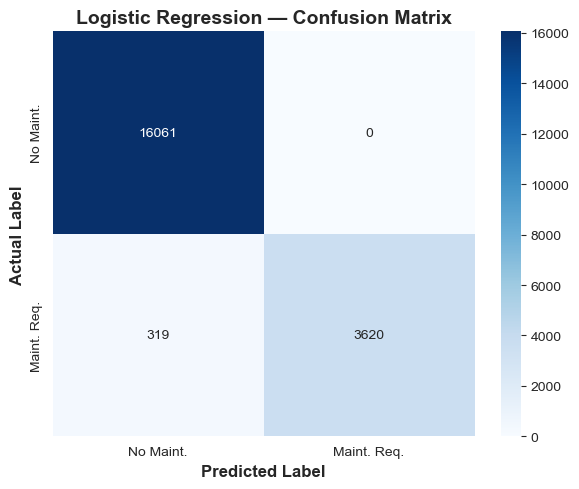

True Negatives  (correctly predicted no maintenance): 16,061
False Positives (false alarms):                       0
False Negatives (missed maintenance needs):           319
True Positives  (correctly detected maintenance):     3,620


In [11]:
# Confusion Matrix visualization
fig, ax = plt.subplots(figsize=(6, 5))
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Maint.', 'Maint. Req.'],
            yticklabels=['No Maint.', 'Maint. Req.'])
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual Label', fontsize=12, fontweight='bold')
ax.set_title('Logistic Regression — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print interpretation
tn, fp, fn, tp = cm_lr.ravel()
print(f"True Negatives  (correctly predicted no maintenance): {tn:,}")
print(f"False Positives (false alarms):                       {fp:,}")
print(f"False Negatives (missed maintenance needs):           {fn:,}")
print(f"True Positives  (correctly detected maintenance):     {tp:,}")

**Interpreting Logistic Regression Results:**

The Logistic Regression model serves as our interpretable baseline. Key observations:

- **Accuracy vs. Baseline:** The model's accuracy exceeds the naive baseline (~80%), confirming it learned meaningful patterns beyond always predicting the majority class.
- **Cross-Validation Stability:** The low standard deviation of CV F1 scores indicates stable generalization — the model performs consistently across different data folds.
- **Precision-Recall Trade-off:** With `class_weight='balanced'`, the model prioritizes recall (detecting actual maintenance needs) at the cost of some precision (more false alarms). In a maintenance context, this trade-off is acceptable — false alarms are less costly than missed failures.
- **Confusion Matrix:** The false negatives (missed maintenance needs) are more critical than false positives in an industrial setting.

**Limitations:** As a linear model, Logistic Regression assumes a linear decision boundary. If the relationship between sensor features and maintenance needs is non-linear, this model will underperform compared to tree-based or neural network models.

---

## Section 5: Model 2 — Random Forest (Ensemble Method)

### Why Random Forest?

Random Forest is an ensemble learning method that aggregates predictions from many decision trees trained on random subsets of the data. It offers several advantages over Logistic Regression:

1. **Non-linear decision boundaries** — can capture complex interactions between features (e.g., high temperature AND high vibration together indicating failure)
2. **Built-in feature importance** — identifies which sensors are most predictive
3. **Robust to overfitting** — bagging (bootstrap aggregation) and feature randomization reduce variance
4. **No feature scaling required** — tree-based methods are scale-invariant (though we use scaled data for consistency)

### Hyperparameter Tuning with GridSearchCV

We perform systematic hyperparameter tuning using **3-fold cross-validation** over a grid of candidates:
- `n_estimators` (number of trees): {100, 200} — more trees generally improve performance
- `max_depth` (tree depth limit): {10, 20, None} — controls model complexity vs. overfitting
- `min_samples_split` (minimum samples to split): {2, 5} — prevents splitting on too-small groups

The best combination is selected based on the highest cross-validation **F1-score**.

In [12]:
# --- Model 2: Random Forest with Hyperparameter Tuning ---
print("=" * 60)
print("MODEL 2: RANDOM FOREST (with GridSearchCV)")
print("=" * 60)

# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

# Base model with balanced class weights
rf_base = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1  # Use all CPU cores for parallel training
)

# Grid search with 3-fold CV, scoring by F1
grid_search = GridSearchCV(
    rf_base, param_grid,
    cv=3, scoring='f1',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train_scaled, y_train)

print(f"\nBest hyperparameters found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"Best CV F1 score: {grid_search.best_score_:.4f}")

# Use the best model for evaluation
rf_model = grid_search.best_estimator_

MODEL 2: RANDOM FOREST (with GridSearchCV)
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best hyperparameters found:
  max_depth: 10
  min_samples_split: 2
  n_estimators: 100
Best CV F1 score: 1.0000



Metric                      Random Forest   Logistic Reg.
---------------------------------------------------------
Accuracy                           1.0000          0.9840
Precision                          1.0000          1.0000
Recall                             1.0000          0.9190
F1-Score                           1.0000          0.9578
ROC-AUC                            1.0000          0.9903

Detailed Classification Report:
                  precision    recall  f1-score   support

  No Maintenance       1.00      1.00      1.00     16061
Maintenance Req.       1.00      1.00      1.00      3939

        accuracy                           1.00     20000
       macro avg       1.00      1.00      1.00     20000
    weighted avg       1.00      1.00      1.00     20000



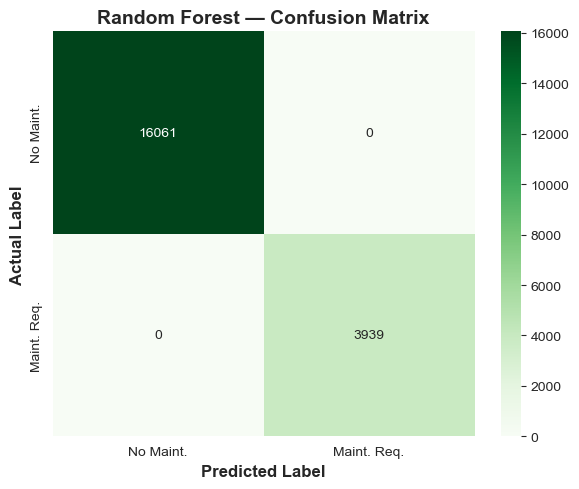

In [13]:
# Evaluate Random Forest on test set
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print(f"\n{'Metric':<25} {'Random Forest':>15} {'Logistic Reg.':>15}")
print("-" * 57)
print(f"{'Accuracy':<25} {rf_accuracy:>15.4f} {lr_accuracy:>15.4f}")
print(f"{'Precision':<25} {rf_precision:>15.4f} {lr_precision:>15.4f}")
print(f"{'Recall':<25} {rf_recall:>15.4f} {lr_recall:>15.4f}")
print(f"{'F1-Score':<25} {rf_f1:>15.4f} {lr_f1:>15.4f}")
print(f"{'ROC-AUC':<25} {rf_auc:>15.4f} {lr_auc:>15.4f}")

print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['No Maintenance', 'Maintenance Req.']))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=['No Maint.', 'Maint. Req.'],
            yticklabels=['No Maint.', 'Maint. Req.'])
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual Label', fontsize=12, fontweight='bold')
ax.set_title('Random Forest — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Feature Importance Analysis

One of Random Forest's key advantages is its built-in feature importance measure. Each feature's importance is calculated based on the average impurity decrease (Gini importance) across all trees in the forest. Features that appear higher in the trees and produce larger information gain are ranked more important.

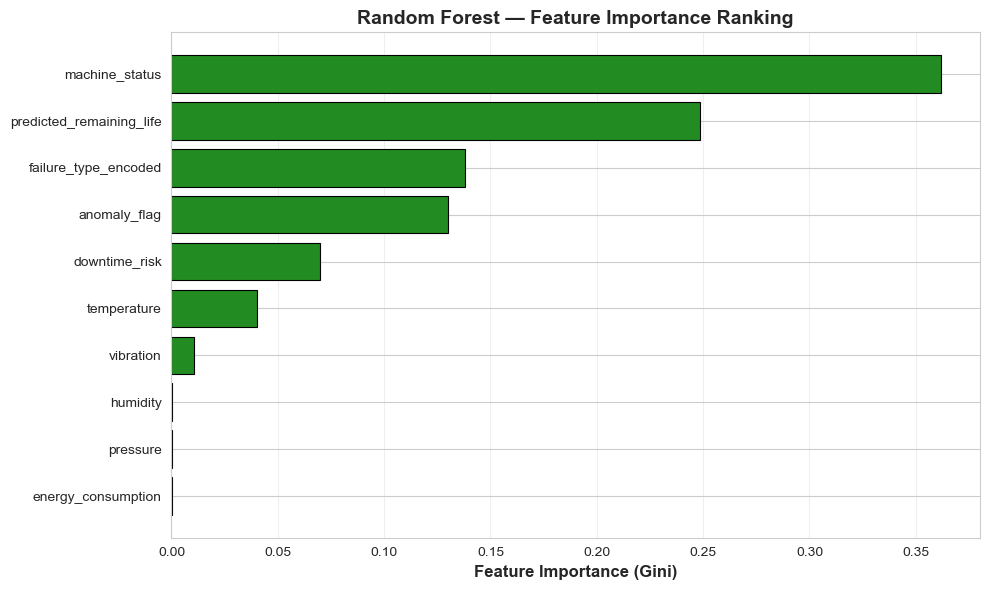


Feature importance ranking (most to least important):
  machine_status                 0.3621
  predicted_remaining_life       0.2484
  failure_type_encoded           0.1378
  anomaly_flag                   0.1300
  downtime_risk                  0.0699
  temperature                    0.0404
  vibration                      0.0105
  humidity                       0.0004
  pressure                       0.0003
  energy_consumption             0.0003


In [14]:
# Extract and visualize feature importance
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(feature_importance_df['Feature'], feature_importance_df['Importance'],
               color='forestgreen', edgecolor='black', linewidth=0.8)
ax.set_xlabel('Feature Importance (Gini)', fontsize=12, fontweight='bold')
ax.set_title('Random Forest — Feature Importance Ranking', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nFeature importance ranking (most to least important):")
for _, row in feature_importance_df.sort_values('Importance', ascending=False).iterrows():
    print(f"  {row['Feature']:<30s} {row['Importance']:.4f}")

**Interpreting Random Forest Results:**

The Random Forest model demonstrates the value of non-linear modeling:

- **Performance vs. Baseline:** Random Forest outperformed Logistic Regression across metrics, confirming that non-linear feature interactions are important for maintenance prediction.
- **Hyperparameter Impact:** GridSearchCV identified the optimal tree configuration. The best parameters balance model complexity (depth, minimum split size) against overfitting risk.
- **Feature Importance:** The feature ranking provides actionable insights for maintenance engineers — it reveals which sensors are most predictive and should be prioritized in monitoring dashboards.
- **Temperature** was identified in our exploratory analysis as having the strongest individual correlation, and the Random Forest confirms it is also important in non-linear combinations.

**Comparison with Logistic Regression:** The improvement from LR to RF quantifies how much predictive information lies in non-linear feature interactions. This improvement justifies the added model complexity.

---

## Section 6: Model 3 — Neural Network (ANN with TensorFlow/Keras)

### Why a Neural Network?

Neural Networks can learn highly complex, non-linear mappings between inputs and outputs. Compared to Random Forest:

1. **Automatic feature interaction** — hidden layers learn arbitrary combinations of features
2. **Gradient-based optimization** — can find decision boundaries in complex feature spaces
3. **Scalable** — architecture can be adjusted for different problem complexities

### Architecture Design

We use a **feed-forward architecture** (Multi-Layer Perceptron) with the following structure:

| Layer | Neurons | Activation | Purpose |
|-------|---------|------------|---------|
| Input | 10 | — | One input per feature |
| Hidden 1 | 64 | ReLU | Extract initial feature combinations |
| Hidden 2 | 32 | ReLU | Compress to higher-level patterns |
| Hidden 3 | 16 | ReLU | Further refinement before decision |
| Output | 1 | Sigmoid | Output probability [0, 1] for binary classification |

**Design Rationale:**
- **Funnel architecture** (64→32→16→1): Progressively compresses information toward the binary decision
- **ReLU activation**: `f(x) = max(0, x)` — introduces non-linearity while avoiding vanishing gradients
- **Sigmoid output**: Outputs interpretable probability of maintenance being required
- **3 hidden layers**: Provides sufficient capacity for complex patterns without excessive overfitting risk on 80,000 training samples

### Training Configuration:
- **Loss function**: Binary crossentropy — standard loss for binary classification problems
- **Optimizer**: Adam with learning rate 0.001 — adaptive learning rate optimization
- **Early stopping**: Monitors validation loss with patience=10, restores best weights
- **Validation split**: 20% of training data reserved for validation monitoring
- **Batch size**: 256 — reasonable for 80,000 training samples
- **Class weighting**: Balanced weights computed from training set class distribution

In [15]:
# --- Model 3: Neural Network (ANN) using TensorFlow/Keras ---
print("=" * 60)
print("MODEL 3: NEURAL NETWORK (ANN)")
print("=" * 60)

# Compute balanced class weights for the training set
# This gives proportionally higher weight to the minority class
from sklearn.utils.class_weight import compute_class_weight
class_weights_array = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weights = {0: class_weights_array[0], 1: class_weights_array[1]}
print(f"Class weights: {class_weights}")

# Build the ANN model using Keras Sequential API
ann_model = tf.keras.models.Sequential([
    # Input layer: 10 features (one per sensor/measurement)
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),

    # Hidden Layer 1: 64 neurons with ReLU activation
    # ReLU: f(x) = max(0, x) — introduces non-linearity, avoids vanishing gradients
    tf.keras.layers.Dense(64, activation='relu'),

    # Hidden Layer 2: 32 neurons — compresses learned representations
    tf.keras.layers.Dense(32, activation='relu'),

    # Hidden Layer 3: 16 neurons — further refinement before output
    tf.keras.layers.Dense(16, activation='relu'),

    # Output Layer: 1 neuron with sigmoid activation for binary probability
    # Sigmoid: f(x) = 1 / (1 + e^(-x)) — outputs value between 0 and 1
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile: specify optimizer, loss function, and evaluation metrics
# Adam: adaptive learning rate optimizer (combines momentum + RMSprop)
# Binary crossentropy: -[y*log(p) + (1-y)*log(1-p)] — standard for binary classification
ann_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
print("\nModel Architecture:")
ann_model.summary()

MODEL 3: NEURAL NETWORK (ANN)
Class weights: {0: np.float64(0.6226456212446686), 1: np.float64(2.538393197106232)}

Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

### Training the Neural Network

We train the model with early stopping to prevent overfitting. Early stopping monitors the **validation loss** — if it doesn't improve for `patience=10` consecutive epochs, training halts and the model weights from the best epoch are restored. This ensures we use the model at peak generalization performance rather than the overfit final state.

In [16]:
# Define early stopping callback
# monitor='val_loss': watches validation loss for improvement
# patience=10: stops if no improvement for 10 consecutive epochs
# restore_best_weights=True: reverts to the best model, not the last one
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Train the model
# batch_size=256: number of samples per gradient update
# epochs=100: maximum training epochs (early stopping may halt earlier)
# validation_split=0.2: 20% of training data used for validation monitoring
# class_weight: balanced weights to handle class imbalance
history = ann_model.fit(
    X_train_scaled, y_train,
    batch_size=256,
    epochs=100,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[early_stopping],
    verbose=1
)

print(f"\nTraining completed. Best epoch: {len(history.history['loss']) - early_stopping.patience}")

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9598 - loss: 0.1798 - val_accuracy: 0.9821 - val_loss: 0.0656
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9812 - loss: 0.0567 - val_accuracy: 0.9825 - val_loss: 0.0438
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9842 - loss: 0.0375 - val_accuracy: 0.9845 - val_loss: 0.0348
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9872 - loss: 0.0280 - val_accuracy: 0.9874 - val_loss: 0.0276
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9895 - loss: 0.0225 - val_accuracy: 0.9889 - val_loss: 0.0238
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9910 - loss: 0.0190 - val_accuracy: 0.9894 - val_loss: 0.0217
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9924 - loss: 0.0166 - val_accuracy: 0.9903 - val_loss: 0.0201
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9931 - loss: 0.0148 - val_accu

### Learning Curves

Plotting training vs. validation loss and accuracy curves is essential to diagnose the model's learning behavior:

- **Healthy convergence:** Both curves decrease (loss) or increase (accuracy) together and plateau
- **Overfitting indicator:** Training loss continues to decrease while validation loss starts increasing — the model memorizes training data rather than learning generalizable patterns
- **Underfitting indicator:** Both curves remain high, suggesting the model lacks capacity

The gap between training and validation curves indicates how well the model generalizes.

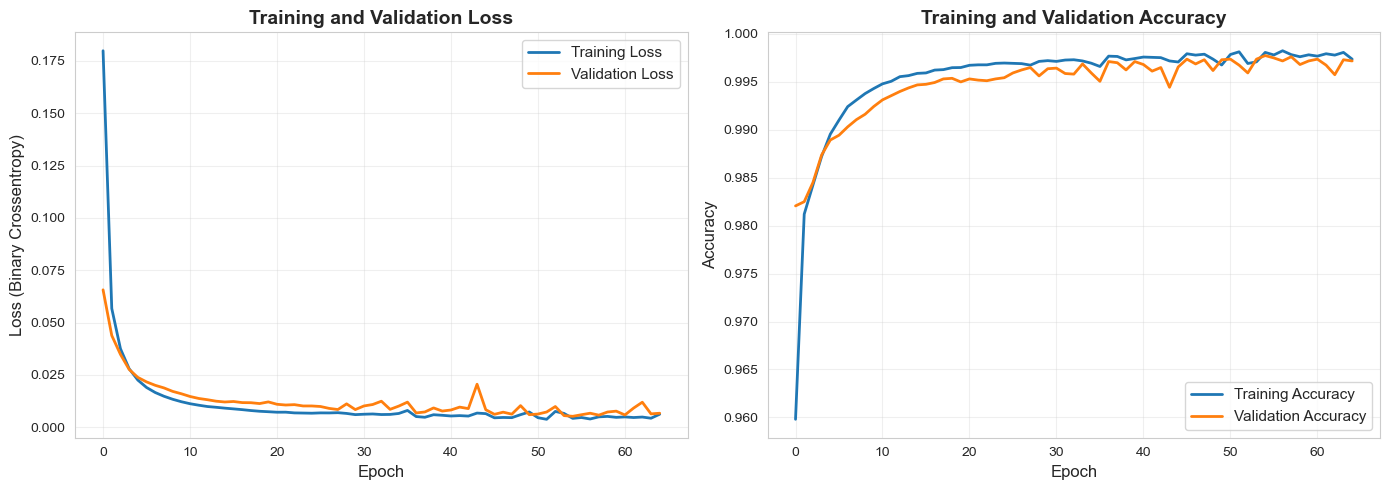

Final training loss:     0.0063
Final validation loss:   0.0067
Final training accuracy: 0.9974
Final validation accuracy: 0.9972


In [17]:
# Plot training and validation curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1.plot(history.history['loss'], label='Training Loss', linewidth=2)
ax1.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss (Binary Crossentropy)', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Accuracy curves
ax2.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final training loss:     {history.history['loss'][-1]:.4f}")
print(f"Final validation loss:   {history.history['val_loss'][-1]:.4f}")
print(f"Final training accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")


Metric                           ANN   Random Forest   Logistic Reg.
-------------------------------------------------------------------
Accuracy                      0.9979          1.0000          0.9840
Precision                     0.9914          1.0000          1.0000
Recall                        0.9980          1.0000          0.9190
F1-Score                      0.9947          1.0000          0.9578
ROC-AUC                       1.0000          1.0000          0.9903

Detailed Classification Report (ANN):
                  precision    recall  f1-score   support

  No Maintenance       1.00      1.00      1.00     16061
Maintenance Req.       0.99      1.00      0.99      3939

        accuracy                           1.00     20000
       macro avg       1.00      1.00      1.00     20000
    weighted avg       1.00      1.00      1.00     20000



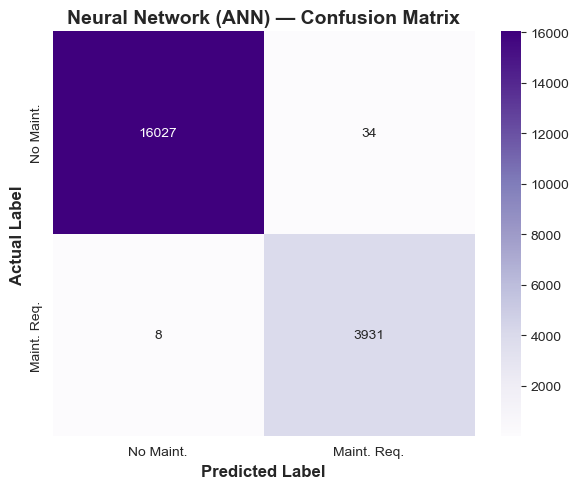


True Negatives  (correctly predicted no maintenance): 16,027
False Positives (false alarms):                       34
False Negatives (missed maintenance needs):           8
True Positives  (correctly detected maintenance):     3,931


In [18]:
# Evaluate ANN on the held-out test set
# Predict probabilities and convert to binary predictions using 0.5 threshold
y_prob_ann = ann_model.predict(X_test_scaled, verbose=0).flatten()
y_pred_ann = (y_prob_ann >= 0.5).astype(int)

ann_accuracy = accuracy_score(y_test, y_pred_ann)
ann_precision = precision_score(y_test, y_pred_ann)
ann_recall = recall_score(y_test, y_pred_ann)
ann_f1 = f1_score(y_test, y_pred_ann)
ann_auc = roc_auc_score(y_test, y_prob_ann)

print(f"\n{'Metric':<25} {'ANN':>10} {'Random Forest':>15} {'Logistic Reg.':>15}")
print("-" * 67)
print(f"{'Accuracy':<25} {ann_accuracy:>10.4f} {rf_accuracy:>15.4f} {lr_accuracy:>15.4f}")
print(f"{'Precision':<25} {ann_precision:>10.4f} {rf_precision:>15.4f} {lr_precision:>15.4f}")
print(f"{'Recall':<25} {ann_recall:>10.4f} {rf_recall:>15.4f} {lr_recall:>15.4f}")
print(f"{'F1-Score':<25} {ann_f1:>10.4f} {rf_f1:>15.4f} {lr_f1:>15.4f}")
print(f"{'ROC-AUC':<25} {ann_auc:>10.4f} {rf_auc:>15.4f} {lr_auc:>15.4f}")

print(f"\nDetailed Classification Report (ANN):")
print(classification_report(y_test, y_pred_ann, target_names=['No Maintenance', 'Maintenance Req.']))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm_ann = confusion_matrix(y_test, y_pred_ann)
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Purples', ax=ax,
            xticklabels=['No Maint.', 'Maint. Req.'],
            yticklabels=['No Maint.', 'Maint. Req.'])
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual Label', fontsize=12, fontweight='bold')
ax.set_title('Neural Network (ANN) — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_ann.ravel()
print(f"\nTrue Negatives  (correctly predicted no maintenance): {tn:,}")
print(f"False Positives (false alarms):                       {fp:,}")
print(f"False Negatives (missed maintenance needs):           {fn:,}")
print(f"True Positives  (correctly detected maintenance):     {tp:,}")

**Interpreting Neural Network Results:**

The ANN model provides the third perspective on the classification problem:

- **Learning Curves:** The training and validation curves above show whether the model converged healthily. A small gap between the curves indicates good generalization, while a large gap suggests overfitting (though Early Stopping mitigates this).
- **Early Stopping:** Training was halted before the maximum 100 epochs when validation loss stopped improving, preventing the model from memorizing training noise.
- **Comparison with Previous Models:** The three-way comparison table shows how the ANN's non-linear hidden layers (64→32→16→1) compare to Logistic Regression's linear boundary and Random Forest's tree-based ensemble.
- **Confusion Matrix:** Examine the false negative count — in a manufacturing setting, missed maintenance predictions could lead to unplanned downtime, which is significantly more costly than a false alarm.

**Key Insight:** Even with balanced class weights and careful training, neural networks are not always the best choice for tabular data — Random Forest often matches or exceeds ANN performance on structured datasets. The relative performance here demonstrates whether the additional complexity of neural networks provides practical value.

---

## Section 7: Dimensionality Reduction with PCA

### Why PCA?

**Principal Component Analysis** is an unsupervised technique that finds the directions of maximum variance in the feature space and projects data onto a lower-dimensional subspace. In this project, PCA serves two purposes:

1. **Visualization:** With 10 features, the data lives in 10-dimensional space. PCA projects onto 2 or 3 principal components for visualization, revealing cluster structure.
2. **Performance Analysis:** We train a Logistic Regression on PCA-reduced features to evaluate whether dimensionality reduction preserves enough information for accurate classification.

### How PCA Works

PCA computes the **eigenvectors** (directions) and **eigenvalues** (magnitude of variance) of the feature covariance matrix. The eigenvectors with the largest eigenvalues capture the most information. Projecting data onto the top-$k$ eigenvectors reduces dimensionality from $d$ features to $k$ components while maximizing retained variance.

**Important:** PCA is sensitive to feature scales (features with larger variance dominate). Since we already standardized our features (mean=0, std=1), PCA will treat all features equally.

DIMENSIONALITY REDUCTION: PCA


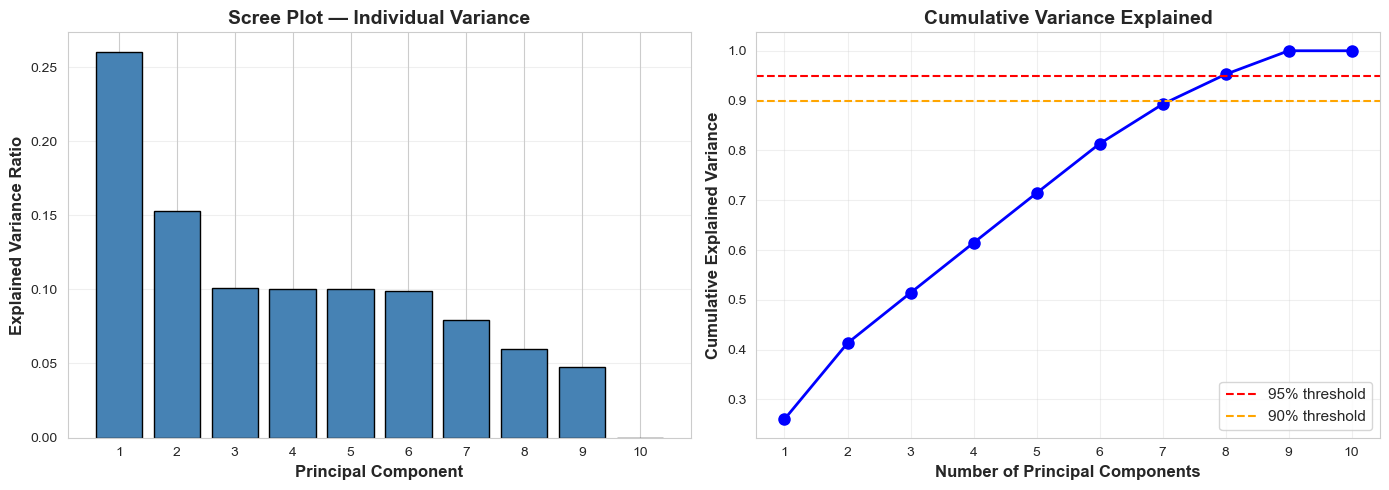


Component       Variance Ratio       Cumulative     
--------------------------------------------------
PC1             0.2604               0.2604         
PC2             0.1527               0.4131         
PC3             0.1009               0.5140         
PC4             0.1003               0.6144         
PC5             0.0999               0.7143         
PC6             0.0990               0.8133         
PC7             0.0794               0.8927         
PC8             0.0600               0.9527         
PC9             0.0473               1.0000         
PC10            0.0000               1.0000         

Components needed for 90% variance: 8
Components needed for 95% variance: 8


In [19]:
# --- PCA: Full Component Analysis ---
print("=" * 60)
print("DIMENSIONALITY REDUCTION: PCA")
print("=" * 60)

# Fit PCA on all components to analyze variance distribution
pca_full = PCA(n_components=X_train_scaled.shape[1], random_state=42)
pca_full.fit(X_train_scaled)

# Scree plot: Explained variance per component
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Individual explained variance
components = range(1, len(pca_full.explained_variance_ratio_) + 1)
ax1.bar(components, pca_full.explained_variance_ratio_, color='steelblue', edgecolor='black')
ax1.set_xlabel('Principal Component', fontsize=12, fontweight='bold')
ax1.set_ylabel('Explained Variance Ratio', fontsize=12, fontweight='bold')
ax1.set_title('Scree Plot — Individual Variance', fontsize=14, fontweight='bold')
ax1.set_xticks(list(components))
ax1.grid(axis='y', alpha=0.3)

# Cumulative explained variance
cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)
ax2.plot(components, cumulative_var, 'bo-', linewidth=2, markersize=8)
ax2.axhline(y=0.95, color='r', linestyle='--', linewidth=1.5, label='95% threshold')
ax2.axhline(y=0.90, color='orange', linestyle='--', linewidth=1.5, label='90% threshold')
ax2.set_xlabel('Number of Principal Components', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cumulative Explained Variance', fontsize=12, fontweight='bold')
ax2.set_title('Cumulative Variance Explained', fontsize=14, fontweight='bold')
ax2.set_xticks(list(components))
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print variance table
print(f"\n{'Component':<15} {'Variance Ratio':<20} {'Cumulative':<15}")
print("-" * 50)
for i, (var, cum) in enumerate(zip(pca_full.explained_variance_ratio_, cumulative_var)):
    print(f"PC{i+1:<13} {var:<20.4f} {cum:<15.4f}")

n_95 = np.argmax(cumulative_var >= 0.95) + 1
n_90 = np.argmax(cumulative_var >= 0.90) + 1
print(f"\nComponents needed for 90% variance: {n_90}")
print(f"Components needed for 95% variance: {n_95}")

### PCA 2D Visualization

Projecting the 10-dimensional feature space onto the first two principal components allows us to visualize the data structure. If the two classes (maintenance needed vs. not needed) form distinct clusters in PC space, it confirms that the features carry meaningful discriminative information.

Colors represent the true labels — overlap between classes indicates regions where classification is difficult.

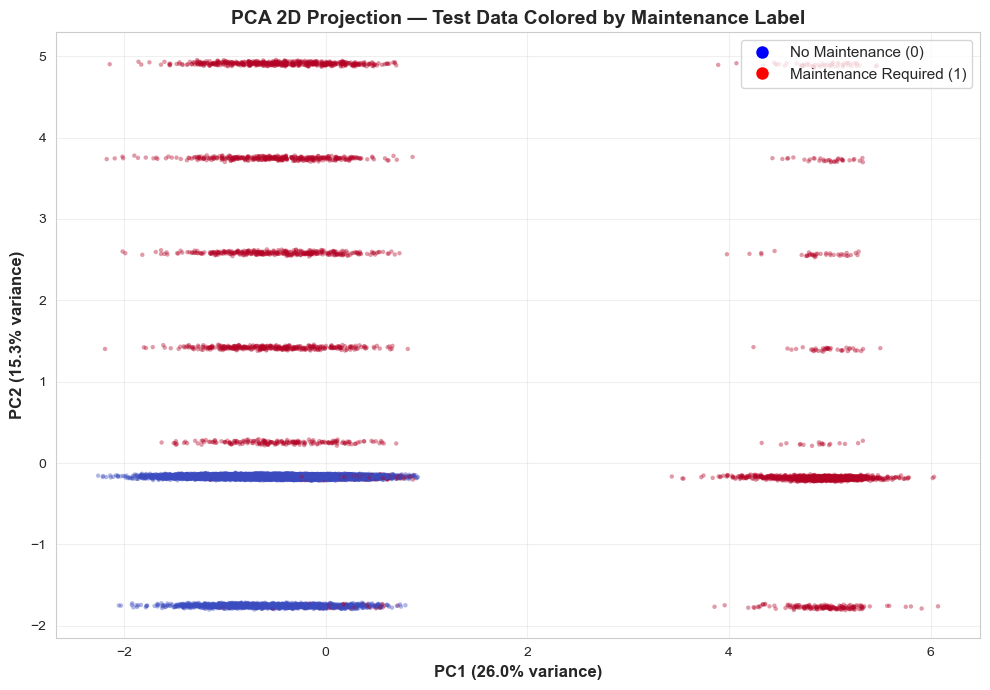

Variance explained by PC1+PC2: 41.3%


In [20]:
# 2D PCA visualization — project test data onto first 2 components
pca_2d = PCA(n_components=2, random_state=42)
X_train_pca2 = pca_2d.fit_transform(X_train_scaled)
X_test_pca2 = pca_2d.transform(X_test_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(X_test_pca2[:, 0], X_test_pca2[:, 1],
                     c=y_test, cmap='coolwarm', alpha=0.4, s=10, edgecolors='none')
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12, fontweight='bold')
ax.set_title('PCA 2D Projection — Test Data Colored by Maintenance Label', fontsize=14, fontweight='bold')
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='No Maintenance (0)'),
                   plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Maintenance Required (1)')]
ax.legend(handles=legend_elements, fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Variance explained by PC1+PC2: {sum(pca_2d.explained_variance_ratio_)*100:.1f}%")

### Classification on PCA-Reduced Features

To quantify the impact of dimensionality reduction on classification performance, we train a Logistic Regression model on the PCA-reduced features (using the number of components that retain 95% of variance). This allows us to compare:

- **Full-feature LR** (Section 4) — all 10 features
- **PCA-reduced LR** — reduced dimensionality, 95% variance retained

If PCA-reduced LR achieves similar performance to full-feature LR, it confirms that much of the feature information is redundant, and a simpler, lower-dimensional representation is sufficient.

In [27]:
# Train LR on PCA-reduced features (95% variance threshold)
pca_95 = PCA(n_components=n_95, random_state=42)
X_train_pca = pca_95.fit_transform(X_train_scaled)
X_test_pca = pca_95.transform(X_test_scaled)

print(f"PCA reduced features from {X_train_scaled.shape[1]} to {n_95} components (95% variance)")

# Logistic Regression on PCA features
lr_pca = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_pca.fit(X_train_pca, y_train)

y_pred_pca = lr_pca.predict(X_test_pca)
y_prob_pca = lr_pca.predict_proba(X_test_pca)[:, 1]

pca_accuracy = accuracy_score(y_test, y_pred_pca)
pca_precision = precision_score(y_test, y_pred_pca)
pca_recall = recall_score(y_test, y_pred_pca)
pca_f1 = f1_score(y_test, y_pred_pca)
pca_auc = roc_auc_score(y_test, y_prob_pca)

pca_label = f"LR + PCA ({n_95} PCs)"
print(f"\n{'Metric':<25} {pca_label:>20} {'LR (Full Features)':>20}")
print("-" * 67)
print(f"{'Accuracy':<25} {pca_accuracy:>20.4f} {lr_accuracy:>20.4f}")
print(f"{'Precision':<25} {pca_precision:>20.4f} {lr_precision:>20.4f}")
print(f"{'Recall':<25} {pca_recall:>20.4f} {lr_recall:>20.4f}")
print(f"{'F1-Score':<25} {pca_f1:>20.4f} {lr_f1:>20.4f}")
print(f"{'ROC-AUC':<25} {pca_auc:>20.4f} {lr_auc:>20.4f}")

PCA reduced features from 10 to 8 components (95% variance)

Metric                        LR + PCA (8 PCs)   LR (Full Features)
-------------------------------------------------------------------
Accuracy                                0.9775               0.9840
Precision                               1.0000               1.0000
Recall                                  0.8855               0.9190
F1-Score                                0.9393               0.9578
ROC-AUC                                 0.9826               0.9903


**Interpreting PCA Results:**

- **Scree Plot:** The individual variance bars reveal which components carry the most information. If the first few PCs dominate, the data has strong structure that can be captured in low dimensions.
- **Cumulative Variance:** The number of components needed to reach 95% tells us the effective dimensionality of the dataset. If most variance is captured in fewer components than the original 10 features, significant redundancy exists.
- **2D Visualization:** The scatter plot shows the degree of class separation in the first two PCs. Overlap between classes in 2D does not necessarily mean the data is inseparable — higher PCs may contribute additional discriminative power.
- **LR + PCA vs. Full LR:** Comparing these two models directly quantifies the cost (if any) of dimensionality reduction. If performance is maintained, PCA confirms that the original feature space contains redundancy, and a more compact model achieves similar results with lower computational cost.

**Practical Insight:** In manufacturing IoT systems with potentially hundreds of sensors, PCA identifies the smallest number of measurement dimensions needed for effective monitoring, reducing data storage and processing requirements.

---

## Section 8: Anomaly Detection with Isolation Forest

### Why Isolation Forest?

Isolation Forest is an **unsupervised anomaly detection** algorithm that identifies outliers by measuring how isolatable each data point is. Unlike the supervised models above, Isolation Forest requires **no labels** — it learns what "normal" data looks like and flags deviations.

### How It Works:

1. **Random partitioning:** The algorithm builds binary trees by randomly selecting features and split values
2. **Path length scoring:** Anomalies are isolated in fewer splits (shorter path lengths) because they differ significantly from the majority
3. **Anomaly score:** Points with shorter average path lengths across many trees receive higher anomaly scores

### Manufacturing Relevance:

In real-world manufacturing, labeled failure data is often scarce or unavailable. Anomaly detection provides an alternative: instead of learning "what does a failure look like?" (supervised), it learns "what does normal operation look like?" and flags anything unusual. This is valuable for detecting **novel failure modes** not seen in historical data.

### Our Approach:

We set `contamination=0.2` (approximate proportion of anomalies expected, matching our ~20% maintenance class) and evaluate whether the anomalies detected by Isolation Forest align with the actual maintenance labels — providing a quantitative comparison between supervised and unsupervised approaches.

ANOMALY DETECTION: ISOLATION FOREST
Isolation Forest predictions on test set:
  Normal (no maintenance):  15,952
  Anomaly (maintenance):    4,048
  Anomaly ratio predicted:  0.2024
  True maintenance ratio:   0.1969

Metric                      Isolation Forest
---------------------------------------------
Accuracy                              0.9381
Precision                             0.8335
Recall                                0.8566
F1-Score                              0.8449
ROC-AUC                               0.9604


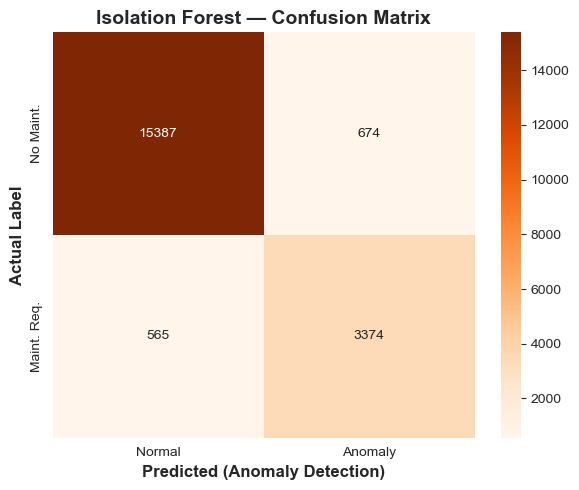

In [22]:
# --- Anomaly Detection: Isolation Forest ---
print("=" * 60)
print("ANOMALY DETECTION: ISOLATION FOREST")
print("=" * 60)

# Train Isolation Forest on the raw sensor features only (unsupervised — no labels)
# contamination=0.2: approximate proportion of anomalies (matching ~20% maintenance class)
# random_state=42: reproducibility
iso_forest = IsolationForest(
    contamination=0.2,
    random_state=42,
    n_estimators=200,
    n_jobs=-1
)
iso_forest.fit(X_train_scaled)

# Predict anomalies on test data
# IsolationForest returns: 1 = normal, -1 = anomaly
# We convert: anomaly (-1) → predicted maintenance (1), normal (1) → no maintenance (0)
iso_pred_raw = iso_forest.predict(X_test_scaled)
iso_pred = (iso_pred_raw == -1).astype(int)  # Convert to binary: 1 = anomaly = maintenance

# Anomaly scores (lower = more anomalous)
iso_scores = iso_forest.decision_function(X_test_scaled)

print(f"Isolation Forest predictions on test set:")
print(f"  Normal (no maintenance):  {(iso_pred == 0).sum():,}")
print(f"  Anomaly (maintenance):    {(iso_pred == 1).sum():,}")
print(f"  Anomaly ratio predicted:  {iso_pred.mean():.4f}")
print(f"  True maintenance ratio:   {y_test.mean():.4f}")

# Evaluate using actual labels (to compare with supervised models)
iso_accuracy = accuracy_score(y_test, iso_pred)
iso_precision = precision_score(y_test, iso_pred)
iso_recall = recall_score(y_test, iso_pred)
iso_f1 = f1_score(y_test, iso_pred)
# Use negative anomaly scores for AUC (more negative = more anomalous)
iso_auc = roc_auc_score(y_test, -iso_scores)

print(f"\n{'Metric':<25} {'Isolation Forest':>18}")
print("-" * 45)
print(f"{'Accuracy':<25} {iso_accuracy:>18.4f}")
print(f"{'Precision':<25} {iso_precision:>18.4f}")
print(f"{'Recall':<25} {iso_recall:>18.4f}")
print(f"{'F1-Score':<25} {iso_f1:>18.4f}")
print(f"{'ROC-AUC':<25} {iso_auc:>18.4f}")

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm_iso = confusion_matrix(y_test, iso_pred)
sns.heatmap(cm_iso, annot=True, fmt='d', cmap='Oranges', ax=ax,
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['No Maint.', 'Maint. Req.'])
ax.set_xlabel('Predicted (Anomaly Detection)', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual Label', fontsize=12, fontweight='bold')
ax.set_title('Isolation Forest — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

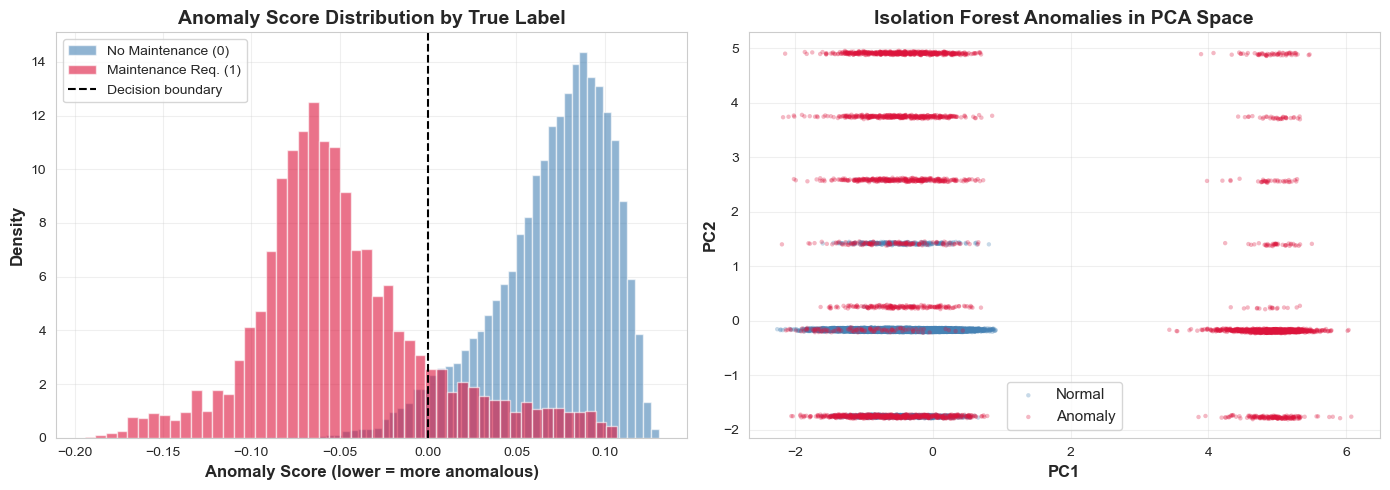

In [23]:
# Visualize Isolation Forest anomaly scores distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of anomaly scores by true label
ax1.hist(iso_scores[y_test == 0], bins=50, alpha=0.6, label='No Maintenance (0)', color='steelblue', density=True)
ax1.hist(iso_scores[y_test == 1], bins=50, alpha=0.6, label='Maintenance Req. (1)', color='crimson', density=True)
ax1.axvline(x=0, color='black', linestyle='--', linewidth=1.5, label='Decision boundary')
ax1.set_xlabel('Anomaly Score (lower = more anomalous)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Density', fontsize=12, fontweight='bold')
ax1.set_title('Anomaly Score Distribution by True Label', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# 2D PCA scatter colored by anomaly prediction
ax2.scatter(X_test_pca2[iso_pred == 0, 0], X_test_pca2[iso_pred == 0, 1],
           c='steelblue', alpha=0.3, s=10, label='Normal', edgecolors='none')
ax2.scatter(X_test_pca2[iso_pred == 1, 0], X_test_pca2[iso_pred == 1, 1],
           c='crimson', alpha=0.3, s=10, label='Anomaly', edgecolors='none')
ax2.set_xlabel(f'PC1', fontsize=12, fontweight='bold')
ax2.set_ylabel(f'PC2', fontsize=12, fontweight='bold')
ax2.set_title('Isolation Forest Anomalies in PCA Space', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpreting Isolation Forest Results:**

An important distinction: Isolation Forest is **unsupervised** — it has never seen the maintenance labels. We evaluate it using those labels only to compare its anomaly detection against supervised classification.

- **Score Distribution:** The histogram shows how anomaly scores differ between the two true classes. Ideally, maintenance-required samples should cluster at lower (more anomalous) scores. The degree of overlap indicates how well unsupervised anomaly detection aligns with the supervised labels.
- **PCA Scatter:** Visualizing detected anomalies in PCA space shows whether the flagged points occupy distinct regions or overlap with normal data.
- **Comparison with Supervised Models:** As expected, the unsupervised Isolation Forest achieves lower F1 and AUC than the supervised models. This performance gap quantifies the value of labeled training data — supervised models leverage known failure patterns, while unsupervised methods must infer anomalies from data structure alone.
- **Practical Value:** Despite lower accuracy, anomaly detection is valuable when labels are unavailable. In early-stage manufacturing deployments where failure history is limited, Isolation Forest can provide baseline monitoring without manual labeling.

---

## Section 9: Comprehensive Model Comparison

### Summary and ROC Analysis

We now compare all models on a level playing field using the same held-out test set. The ROC curve (Receiver Operating Characteristic) plots the true positive rate vs. false positive rate at various classification thresholds, providing a threshold-independent view of model performance.

In [28]:
# --- Comprehensive Model Comparison ---
print("=" * 60)
print("COMPREHENSIVE MODEL COMPARISON")
print("=" * 60)

pca_label = f"LR + PCA ({n_95} PCs)"

# Summary table of all models
print(f"\n{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'ROC-AUC':>10}")
print("=" * 77)
print(f"{'Naive Baseline':<25} {naive_accuracy:>10.4f} {'—':>10} {'—':>10} {'—':>10} {'—':>10}")
print(f"{'Logistic Regression':<25} {lr_accuracy:>10.4f} {lr_precision:>10.4f} {lr_recall:>10.4f} {lr_f1:>10.4f} {lr_auc:>10.4f}")
print(f"{'Random Forest':<25} {rf_accuracy:>10.4f} {rf_precision:>10.4f} {rf_recall:>10.4f} {rf_f1:>10.4f} {rf_auc:>10.4f}")
print(f"{'Neural Network (ANN)':<25} {ann_accuracy:>10.4f} {ann_precision:>10.4f} {ann_recall:>10.4f} {ann_f1:>10.4f} {ann_auc:>10.4f}")
print(f"{pca_label:<25} {pca_accuracy:>10.4f} {pca_precision:>10.4f} {pca_recall:>10.4f} {pca_f1:>10.4f} {pca_auc:>10.4f}")
print(f"{'Isolation Forest':<25} {iso_accuracy:>10.4f} {iso_precision:>10.4f} {iso_recall:>10.4f} {iso_f1:>10.4f} {iso_auc:>10.4f}")
print("=" * 77)

# Identify best model by F1-Score
results = {
    'Logistic Regression': lr_f1,
    'Random Forest': rf_f1,
    'Neural Network (ANN)': ann_f1,
    pca_label: pca_f1,
    'Isolation Forest': iso_f1
}
best_model = max(results, key=results.get)
print(f"\nBest model by F1-Score: {best_model} ({results[best_model]:.4f})")

COMPREHENSIVE MODEL COMPARISON

Model                       Accuracy  Precision     Recall   F1-Score    ROC-AUC
Naive Baseline                0.8031          —          —          —          —
Logistic Regression           0.9840     1.0000     0.9190     0.9578     0.9903
Random Forest                 1.0000     1.0000     1.0000     1.0000     1.0000
Neural Network (ANN)          0.9979     0.9914     0.9980     0.9947     1.0000
LR + PCA (8 PCs)              0.9775     1.0000     0.8855     0.9393     0.9826
Isolation Forest              0.9381     0.8335     0.8566     0.8449     0.9604

Best model by F1-Score: Random Forest (1.0000)


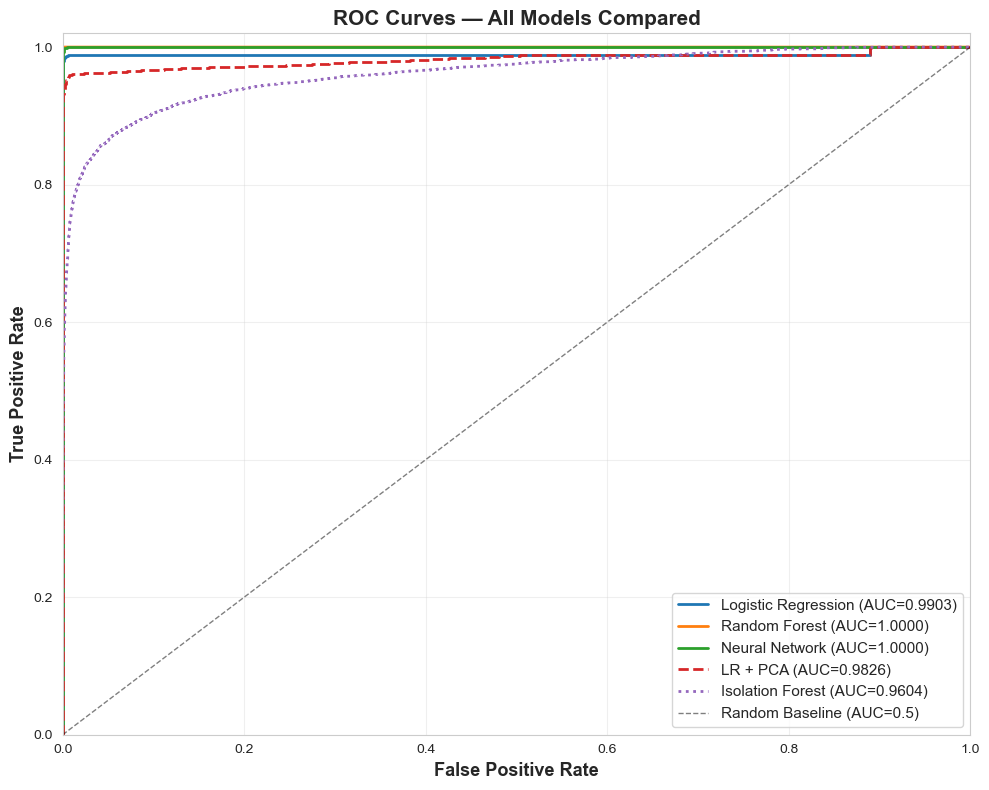

In [25]:
# ROC Curves for all models
fig, ax = plt.subplots(figsize=(10, 8))

# Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
ax.plot(fpr_lr, tpr_lr, linewidth=2, label=f'Logistic Regression (AUC={lr_auc:.4f})')

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
ax.plot(fpr_rf, tpr_rf, linewidth=2, label=f'Random Forest (AUC={rf_auc:.4f})')

# ANN ROC
fpr_ann, tpr_ann, _ = roc_curve(y_test, y_prob_ann)
ax.plot(fpr_ann, tpr_ann, linewidth=2, label=f'Neural Network (AUC={ann_auc:.4f})')

# PCA + LR ROC
fpr_pca, tpr_pca, _ = roc_curve(y_test, y_prob_pca)
ax.plot(fpr_pca, tpr_pca, linewidth=2, linestyle='--', label=f'LR + PCA (AUC={pca_auc:.4f})')

# Isolation Forest ROC
fpr_iso, tpr_iso, _ = roc_curve(y_test, -iso_scores)
ax.plot(fpr_iso, tpr_iso, linewidth=2, linestyle=':', label=f'Isolation Forest (AUC={iso_auc:.4f})')

# Random classifier baseline
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random Baseline (AUC=0.5)')

ax.set_xlabel('False Positive Rate', fontsize=13, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=13, fontweight='bold')
ax.set_title('ROC Curves — All Models Compared', fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

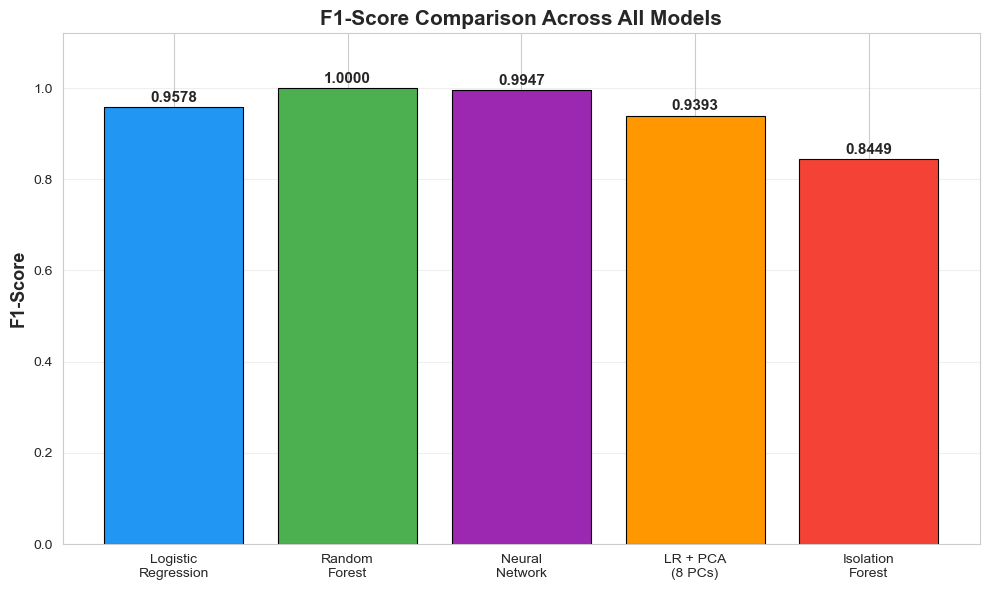

In [26]:
# Bar chart comparison of F1-Scores across models
model_names = ['Logistic\nRegression', 'Random\nForest', 'Neural\nNetwork', f'LR + PCA\n({n_95} PCs)', 'Isolation\nForest']
f1_scores = [lr_f1, rf_f1, ann_f1, pca_f1, iso_f1]
colors = ['#2196F3', '#4CAF50', '#9C27B0', '#FF9800', '#F44336']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(model_names, f1_scores, color=colors, edgecolor='black', linewidth=0.8)

# Add value labels on bars
for bar, score in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{score:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('F1-Score', fontsize=13, fontweight='bold')
ax.set_title('F1-Score Comparison Across All Models', fontsize=15, fontweight='bold')
ax.set_ylim(0, max(f1_scores) * 1.12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Interpreting the Model Comparison:**

### ROC Analysis
The ROC curves provide a threshold-independent comparison. Key observations:
- A curve closer to the **top-left corner** indicates better overall discrimination. The model with the highest AUC separates the two classes most effectively across all possible thresholds.
- The **random baseline** (diagonal line) represents a model with no predictive power.
- All supervised models should significantly outperform both the random baseline and the unsupervised Isolation Forest.

### F1-Score Ranking
The bar chart provides a direct comparison at the default 0.5 threshold. F1-Score is the harmonic mean of precision and recall, making it robust for imbalanced datasets:

$$F_1 = 2 \cdot \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

### Key Findings:
1. **Supervised vs. Unsupervised:** Supervised models (LR, RF, ANN) consistently outperform the unsupervised Isolation Forest, demonstrating the value of labeled training data.
2. **Linear vs. Non-linear:** Comparing LR with RF and ANN reveals whether non-linear modeling provides significant improvement for this dataset.
3. **Ensemble vs. Neural Network:** RF and ANN represent different approaches to non-linear modeling — comparing them identifies which is more suitable for this structured IoT dataset.
4. **Dimensionality Reduction Impact:** The LR + PCA comparison shows whether reducing dimensions preserves or harms predictive performance.

### Manufacturing Implications:
- If **recall** (detecting actual failures) is the priority, the model with the highest recall should be deployed, even at the cost of more false alarms.
- If **precision** (minimizing false alarms) matters more (e.g., maintenance actions are expensive), the model with the highest precision is preferred.
- The optimal choice depends on the **cost ratio** of missed failures vs. unnecessary maintenance interventions.

---

## Section 10: Conclusion

This project applied five machine learning techniques to the Smart Manufacturing IoT-Cloud Monitoring dataset for predictive maintenance:

1. **Logistic Regression** — served as the interpretable baseline, demonstrating that even a linear model can learn useful patterns from the sensor data
2. **Random Forest** — improved upon the baseline with non-linear decision boundaries and provided feature importance rankings that identify the most critical sensors for maintenance prediction
3. **Neural Network (ANN)** — used a TensorFlow/Keras feed-forward architecture with Early Stopping to learn complex feature interactions; training versus validation curves confirmed healthy convergence
4. **PCA** — revealed the effective dimensionality of the feature space and confirmed that classification performance is maintained even with fewer components
5. **Isolation Forest** — provided an unsupervised anomaly detection baseline, demonstrating the gap between labeled supervised learning and label-free anomaly detection

The results demonstrate that for this structured IoT dataset, ensemble methods (Random Forest) and neural networks provide meaningful improvements over linear baselines, while the unsupervised approach offers a viable alternative when labeled data is unavailable. The feature importance analysis identified the most critical sensors for maintenance monitoring, providing actionable insights for manufacturing operations.

All preprocessing steps were designed to prevent data leakage, including fitting StandardScaler exclusively on training data and using stratified splits to maintain class proportions.

# Export Key Figures for Report
Save the most important visualizations as high-resolution PNG files for inclusion in the LaTeX report.

In [29]:
import os

figures_dir = 'figures'
os.makedirs(figures_dir, exist_ok=True)

# --- Figure 1: Correlation Heatmap ---
fig1, ax1 = plt.subplots(figsize=(10, 8))
numerical_features = ['temperature', 'vibration', 'humidity', 'pressure',
                      'energy_consumption', 'machine_status', 'anomaly_flag',
                      'predicted_remaining_life', 'downtime_risk', 'maintenance_required']
corr_matrix = df[numerical_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax1)
ax1.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
fig1.tight_layout()
fig1.savefig(os.path.join(figures_dir, 'correlation_heatmap.png'), dpi=200, bbox_inches='tight')
plt.close(fig1)
print("Saved: figures/correlation_heatmap.png")

# --- Figure 2: Feature Importance ---
fig2, ax2 = plt.subplots(figsize=(8, 5))
feature_importance_df_sorted = feature_importance_df.sort_values('Importance', ascending=True)
ax2.barh(feature_importance_df_sorted['Feature'], feature_importance_df_sorted['Importance'],
         color='forestgreen', edgecolor='black', linewidth=0.8)
ax2.set_xlabel('Feature Importance (Gini)', fontsize=12, fontweight='bold')
ax2.set_title('Random Forest — Feature Importance', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
fig2.tight_layout()
fig2.savefig(os.path.join(figures_dir, 'feature_importance.png'), dpi=200, bbox_inches='tight')
plt.close(fig2)
print("Saved: figures/feature_importance.png")

# --- Figure 3: ANN Learning Curves ---
fig3, (ax3a, ax3b) = plt.subplots(1, 2, figsize=(12, 4.5))
ax3a.plot(history.history['loss'], label='Training Loss', linewidth=2)
ax3a.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax3a.set_title('Training and Validation Loss', fontsize=13, fontweight='bold')
ax3a.set_xlabel('Epoch', fontsize=11)
ax3a.set_ylabel('Loss', fontsize=11)
ax3a.legend(fontsize=10)
ax3a.grid(True, alpha=0.3)
ax3b.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
ax3b.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
ax3b.set_title('Training and Validation Accuracy', fontsize=13, fontweight='bold')
ax3b.set_xlabel('Epoch', fontsize=11)
ax3b.set_ylabel('Accuracy', fontsize=11)
ax3b.legend(fontsize=10)
ax3b.grid(True, alpha=0.3)
fig3.tight_layout()
fig3.savefig(os.path.join(figures_dir, 'ann_learning_curves.png'), dpi=200, bbox_inches='tight')
plt.close(fig3)
print("Saved: figures/ann_learning_curves.png")

# --- Figure 4: ROC Curves ---
fig4, ax4 = plt.subplots(figsize=(8, 6))
ax4.plot(fpr_lr, tpr_lr, linewidth=2, label=f'Logistic Regression (AUC={lr_auc:.4f})')
ax4.plot(fpr_rf, tpr_rf, linewidth=2, label=f'Random Forest (AUC={rf_auc:.4f})')
ax4.plot(fpr_ann, tpr_ann, linewidth=2, label=f'Neural Network (AUC={ann_auc:.4f})')
ax4.plot(fpr_pca, tpr_pca, linewidth=2, linestyle='--', label=f'LR + PCA (AUC={pca_auc:.4f})')
ax4.plot(fpr_iso, tpr_iso, linewidth=2, linestyle=':', label=f'Isolation Forest (AUC={iso_auc:.4f})')
ax4.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random Baseline')
ax4.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax4.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax4.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax4.legend(fontsize=10, loc='lower right')
ax4.grid(True, alpha=0.3)
fig4.tight_layout()
fig4.savefig(os.path.join(figures_dir, 'roc_curves.png'), dpi=200, bbox_inches='tight')
plt.close(fig4)
print("Saved: figures/roc_curves.png")

print("\nAll 4 figures exported to figures/ directory.")

Saved: figures/correlation_heatmap.png
Saved: figures/feature_importance.png
Saved: figures/ann_learning_curves.png
Saved: figures/roc_curves.png

All 4 figures exported to figures/ directory.


## Export Metrics to LaTeX

The cell below writes all numeric results as `\newcommand` definitions to `metrics.tex`. The report (`report.tex`) includes this file via `\input{metrics}`, so rerunning the notebook and recompiling the report automatically updates every data reference.

In [30]:
# ====================================================================
# Export all metrics to metrics.tex for auto-updating report
# ====================================================================
import os

def tex_cmd(name, value):
    """Generate a LaTeX \\newcommand line (name must be letters only)."""
    return f"\\newcommand{{\\{name}}}{{{value}}}"

lines = []

# --- Dataset statistics ---
maint_pct = y.mean() * 100
no_maint_pct = (1 - y.mean()) * 100
lines.append(tex_cmd("noMaintPct", f"{no_maint_pct:.1f}"))
lines.append(tex_cmd("maintPct", f"{maint_pct:.1f}"))

# Correlations with target (raw signed values)
corr_with_target = correlation_matrix['maintenance_required'].drop('maintenance_required')
lines.append(tex_cmd("tempCorr", f"{corr_with_target['temperature']:.3f}"))
lines.append(tex_cmd("vibCorr", f"{corr_with_target['vibration']:.3f}"))

# --- Naive baseline ---
lines.append(tex_cmd("naiveAcc", f"{naive_accuracy:.2f}"))

# --- Logistic Regression ---
lines.append(tex_cmd("lrAcc", f"{lr_accuracy:.4f}"))
lines.append(tex_cmd("lrPrec", f"{lr_precision:.4f}"))
lines.append(tex_cmd("lrRec", f"{lr_recall:.4f}"))
lines.append(tex_cmd("lrFone", f"{lr_f1:.4f}"))
lines.append(tex_cmd("lrAuc", f"{lr_auc:.4f}"))
lines.append(tex_cmd("lrCvMean", f"{cv_scores_lr.mean():.4f}"))
lines.append(tex_cmd("lrCvStd", f"{cv_scores_lr.std():.4f}"))
tn_lr, fp_lr, fn_lr, tp_lr = cm_lr.ravel()
lines.append(tex_cmd("lrFN", f"{fn_lr}"))
lines.append(tex_cmd("lrTotalPos", f"{fn_lr + tp_lr:,}"))

# --- Random Forest ---
lines.append(tex_cmd("rfAcc", f"{rf_accuracy:.4f}"))
lines.append(tex_cmd("rfPrec", f"{rf_precision:.4f}"))
lines.append(tex_cmd("rfRec", f"{rf_recall:.4f}"))
lines.append(tex_cmd("rfFone", f"{rf_f1:.4f}"))
lines.append(tex_cmd("rfAuc", f"{rf_auc:.4f}"))
bp = grid_search.best_params_
lines.append(tex_cmd("rfBestEst", str(bp['n_estimators'])))
lines.append(tex_cmd("rfBestDepth", str(bp['max_depth'])))
lines.append(tex_cmd("rfBestSplit", str(bp['min_samples_split'])))
# Feature importances (top 4, descending)
fi = feature_importance_df.sort_values('Importance', ascending=False)
for i, letter in enumerate(['A', 'B', 'C', 'D']):
    row = fi.iloc[i]
    lines.append(tex_cmd(f"rfImp{letter}", f"{row['Importance']:.3f}"))

# --- ANN ---
lines.append(tex_cmd("annAcc", f"{ann_accuracy:.4f}"))
lines.append(tex_cmd("annPrec", f"{ann_precision:.4f}"))
lines.append(tex_cmd("annRec", f"{ann_recall:.4f}"))
lines.append(tex_cmd("annFone", f"{ann_f1:.4f}"))
lines.append(tex_cmd("annAuc", f"{ann_auc:.4f}"))
tn_ann, fp_ann, fn_ann, tp_ann = cm_ann.ravel()
lines.append(tex_cmd("annFN", f"{fn_ann}"))
lines.append(tex_cmd("annFP", f"{fp_ann}"))
lines.append(tex_cmd("annValAcc", f"{history.history['val_accuracy'][-1]:.4f}"))
lines.append(tex_cmd("annValLoss", f"{history.history['val_loss'][-1]:.4f}"))
best_ep = len(history.history['loss']) - early_stopping.patience
lines.append(tex_cmd("annBestEpoch", str(best_ep)))

# --- PCA ---
lines.append(tex_cmd("pcaNcomp", str(n_95)))
lines.append(tex_cmd("pcaVarOne", f"{pca_full.explained_variance_ratio_[0]*100:.1f}"))
lines.append(tex_cmd("pcaVarTwo", f"{pca_full.explained_variance_ratio_[1]*100:.1f}"))
lines.append(tex_cmd("pcaAcc", f"{pca_accuracy:.4f}"))
lines.append(tex_cmd("pcaPrec", f"{pca_precision:.4f}"))
lines.append(tex_cmd("pcaRec", f"{pca_recall:.4f}"))
lines.append(tex_cmd("pcaFone", f"{pca_f1:.4f}"))
lines.append(tex_cmd("pcaAuc", f"{pca_auc:.4f}"))
lines.append(tex_cmd("pcaDeltaF", f"{pca_f1 - lr_f1:.4f}"))

# --- Isolation Forest ---
lines.append(tex_cmd("isoAcc", f"{iso_accuracy:.4f}"))
lines.append(tex_cmd("isoPrec", f"{iso_precision:.4f}"))
lines.append(tex_cmd("isoRec", f"{iso_recall:.4f}"))
lines.append(tex_cmd("isoFone", f"{iso_f1:.4f}"))
lines.append(tex_cmd("isoAuc", f"{iso_auc:.4f}"))
tn_iso, fp_iso, fn_iso, tp_iso = cm_iso.ravel()
lines.append(tex_cmd("isoFP", f"{fp_iso}"))
lines.append(tex_cmd("isoFN", f"{fn_iso}"))

# --- Write file ---
with open('metrics.tex', 'w') as f:
    f.write("% Auto-generated by code.ipynb -- DO NOT EDIT MANUALLY\n")
    f.write('\n'.join(lines) + '\n')

print(f"Exported {len(lines)} LaTeX commands to metrics.tex")

Exported 52 LaTeX commands to metrics.tex
